# Inspect train/eval splits

Grid of overhead images per split (`train`, `eval/unseen_pos_speaker`, `eval/unseen_pos`, `eval/unseen_layout`):
segmentation mask overlaid (green) + center-of-mass crosshair + speaker icon + metadata title.

In [1]:
import sys, json
from pathlib import Path
sys.path.append(str(Path().resolve().parent / "src3"))

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from io_utils import load
from overhead_pipeline import draw_mask, draw_speaker, center_of_mass
from dataset import build_dataset

BASE_DIR = Path("/home/ethantu/workspace/good-vibrations/data")
MDS_PATH = BASE_DIR / "mds/c1650bbbf41d93b8"
OVERHEAD_DIR = BASE_DIR / "samples_overhead"

/home/ethantu/workspace/good-vibrations/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [2]:
# build_dataset's split logic, reused so we inspect exactly what training sees
train_loader, eval_loaders, _ = build_dataset(MDS_PATH, num_workers=0, verbose=1)

splits = {"train": train_loader.dataloader.dataset.indices}
splits.update({ev.label: ev.dataloader.dataloader.dataset.indices for ev in eval_loaders})

lines = (MDS_PATH / "dataset.jsonl").read_text().strip().splitlines()
index = [json.loads(line) for line in lines[1:] if line]  # per-sample metadata, same order as MDS shards

{label: len(idxs) for label, idxs in splits.items()}

688 total samples, 688 after filtering -> train=511, eval/unseen_pos_speaker=33, eval/unseen_pos=96, eval/unseen_layout=48


{'train': 511,
 'eval/unseen_pos_speaker': 33,
 'eval/unseen_pos': 96,
 'eval/unseen_layout': 48}

In [ ]:
import textwrap
from PIL import ImageDraw, ImageFont

try: FONT = ImageFont.truetype("arial.ttf", 11)
except: FONT = ImageFont.load_default()

def draw_description(overhead: Image.Image, description: str) -> Image.Image:
    """Write `description` into the gray padding at the bottom of the image (added by draw_speaker), wrapping to fit the width."""
    W, H = overhead.size
    draw = ImageDraw.Draw(overhead)

    # shrink chars-per-line until every wrapped line fits within W
    chars_per_line = len(description)
    while chars_per_line > 1:
        lines = textwrap.wrap(description, width=chars_per_line)
        if max(draw.textbbox((0, 0), line, font=FONT)[2] for line in lines) <= W - 4: break
        chars_per_line -= 1
    text = "\n".join(lines)

    draw.text((W // 2, H - 4), text, fill=(0, 0, 0, 255), font=FONT, anchor="md", align="center")
    return overhead


def sample_overhead(meta: dict) -> Image.Image:
    """overhead image with the segmentation mask overlaid, center-of-mass crosshair, speaker icon, and description."""
    output_id = meta["output_id"]
    overhead = load(OVERHEAD_DIR / output_id / "01_resized_overhead.png")
    segment_mask = load(OVERHEAD_DIR / output_id / "02_segment_mask.png")
    # recompute com from the mask actually on disk -- the `com` stored in dataset.jsonl can go stale
    # if the mask was resegmented after metadata was written, which misaligns the crosshair
    com = (-1, -1) if meta["is_empty_box"] else center_of_mass(segment_mask)
    overhead = draw_mask(overhead, segment_mask, com, meta["is_empty_box"])
    overhead = draw_speaker(overhead, meta["speaker"])
    overhead = draw_description(overhead, meta["description"])
    return overhead


def sample_title(meta: dict) -> str:
    return (
        f"sample={meta['sample_id']} output={meta['output_id']}\n"
        f"box={meta['box']} object={meta['object']} n_obj={meta['n_objects']}\n"
        f"speaker={meta['speaker']} empty={meta['is_empty_box']}"
    )

In [ ]:
def plot_split(label: str, idxs: list[int], n_cols: int = 4, max_samples: int = 30):
    idxs = sorted(idxs, key=lambda i: index[i]["sample_id"])[:max_samples]
    n_rows = -(-len(idxs) // n_cols)  # ceil

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.5 * n_cols, 4.2 * n_rows))
    fig.suptitle(f"{label}  ({len(idxs)}/{len(idxs)} shown)", fontsize=16)
    axes = np.atleast_1d(axes).reshape(-1)

    for ax, idx in zip(axes, idxs):
        meta = index[idx]
        ax.imshow(sample_overhead(meta))
        ax.set_title(sample_title(meta), fontsize=8)
        ax.axis("off")
    for ax in axes[len(idxs):]:
        ax.axis("off")

    fig.tight_layout(h_pad=0.3)
    return fig

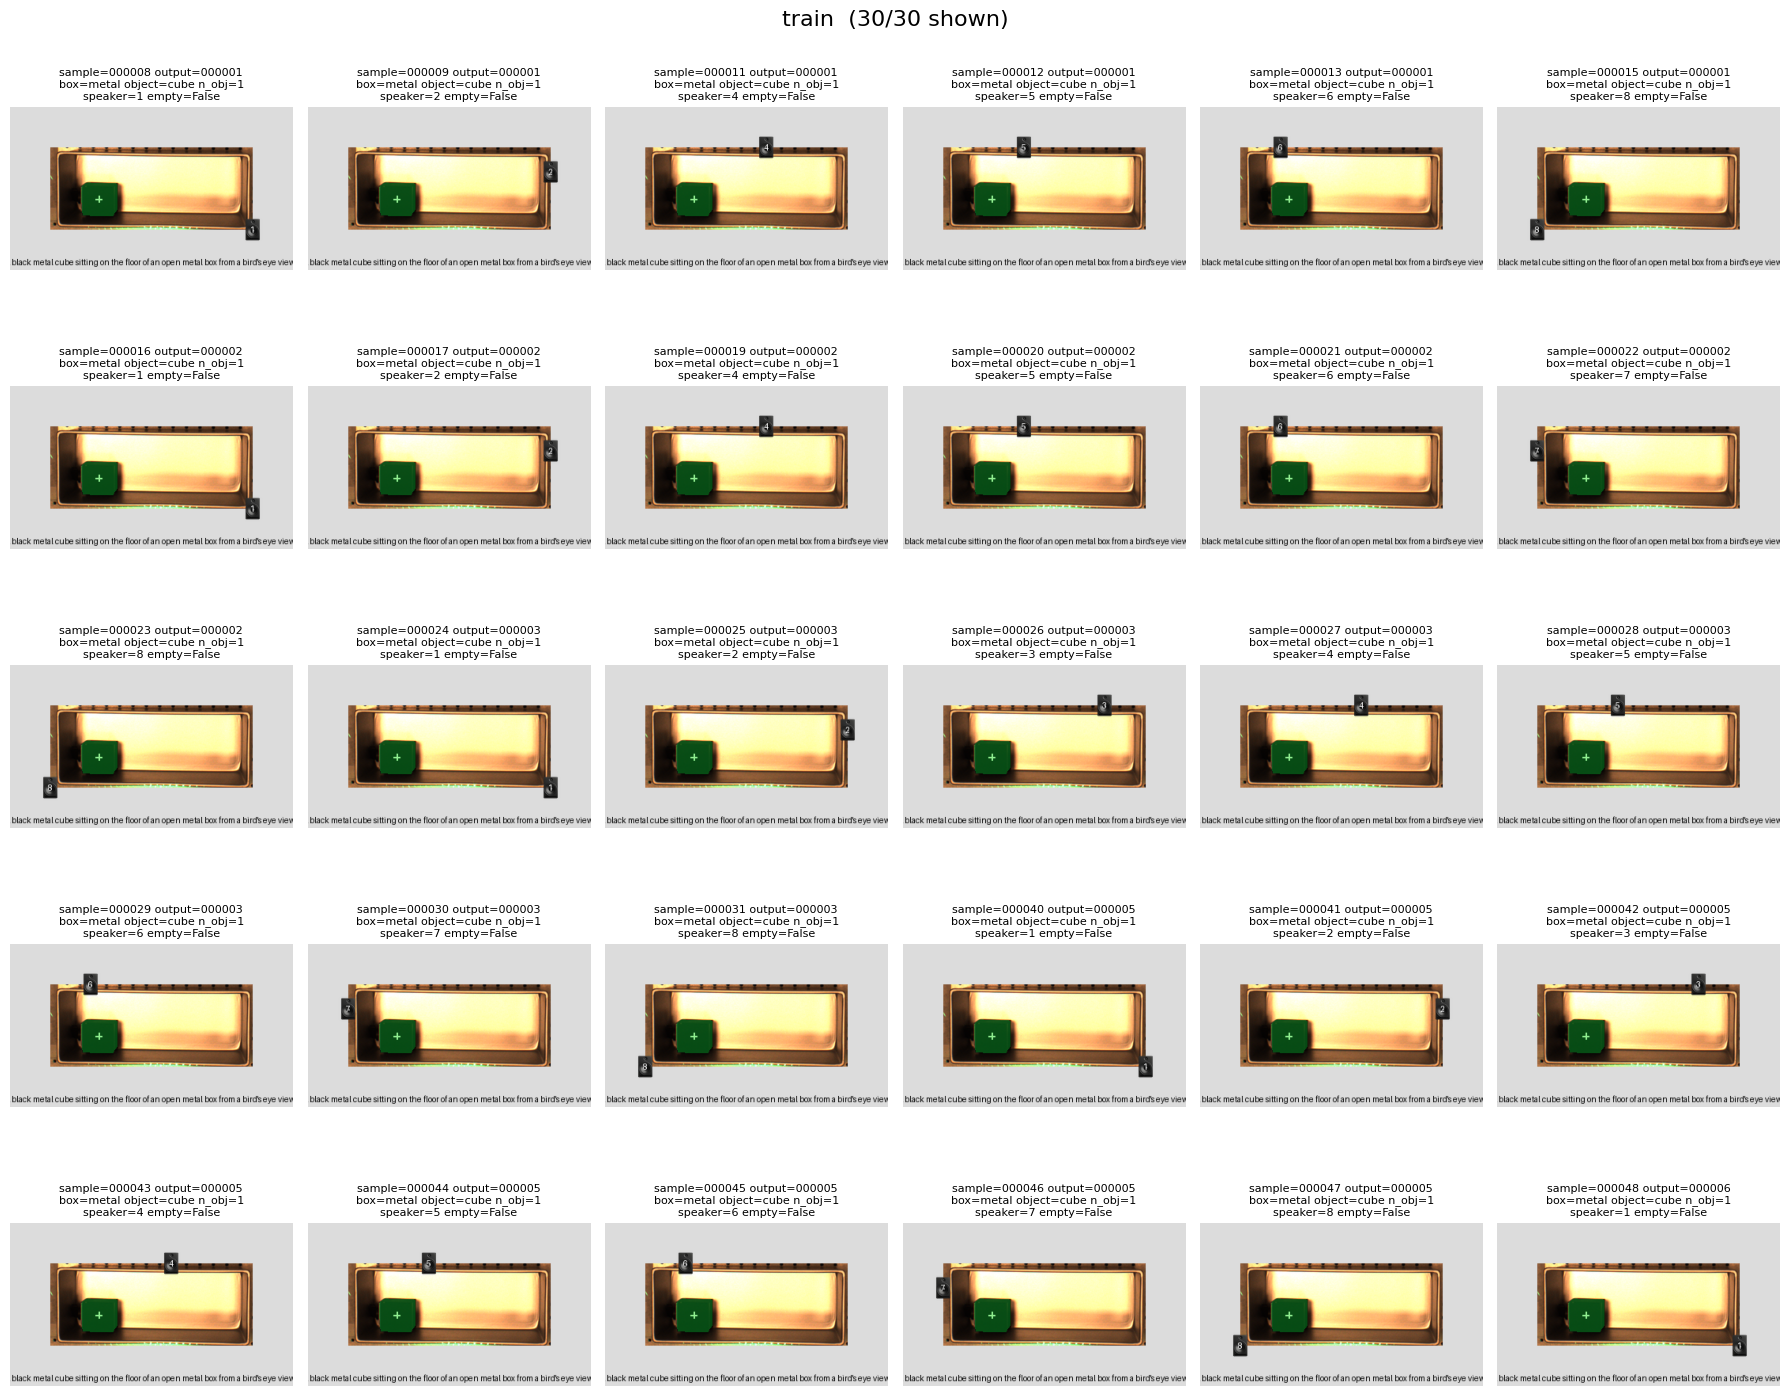

In [5]:
plot_split("train", splits["train"]);

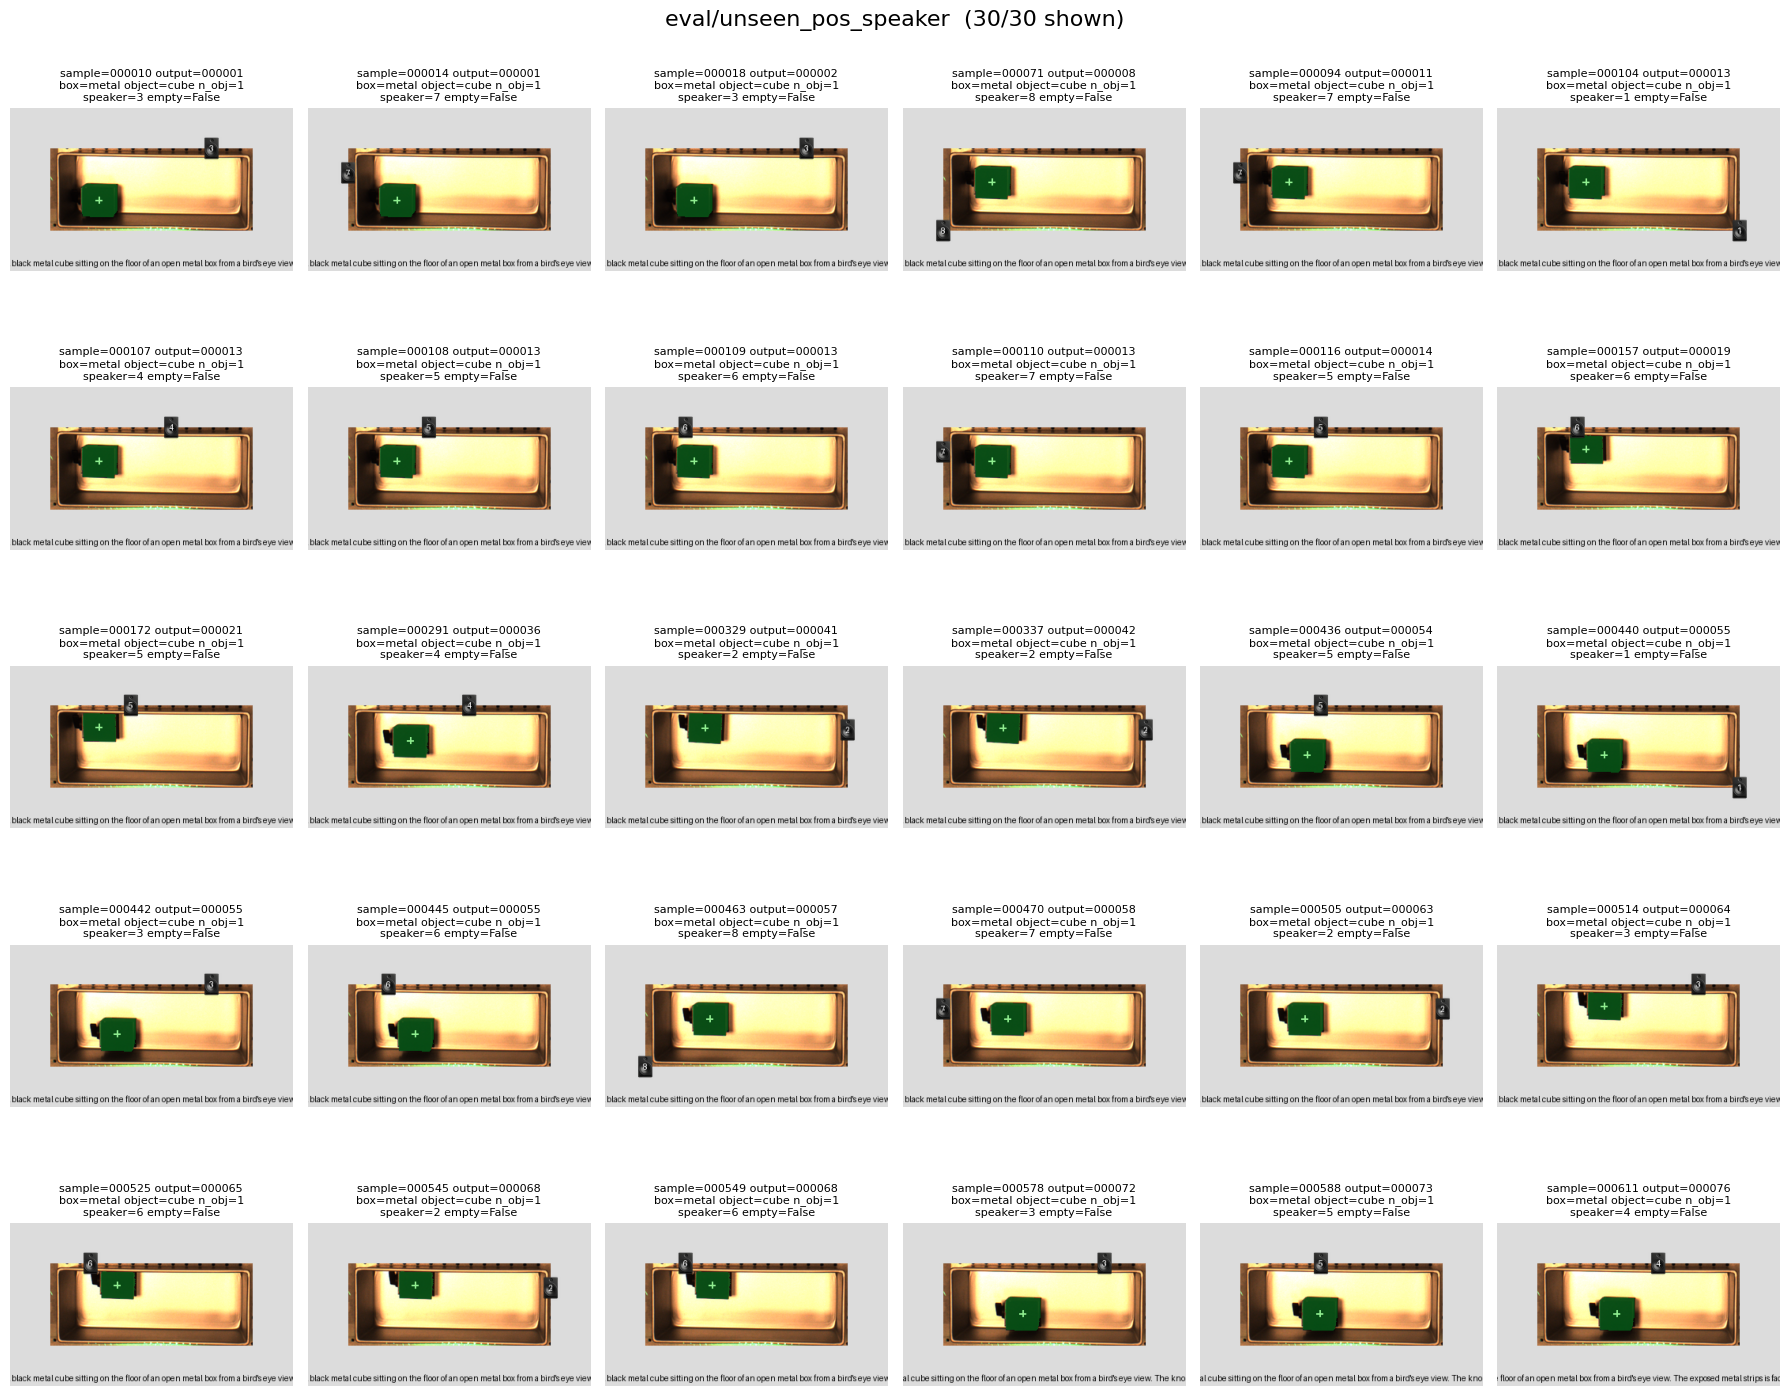

In [6]:
plot_split("eval/unseen_pos_speaker", splits["eval/unseen_pos_speaker"]);

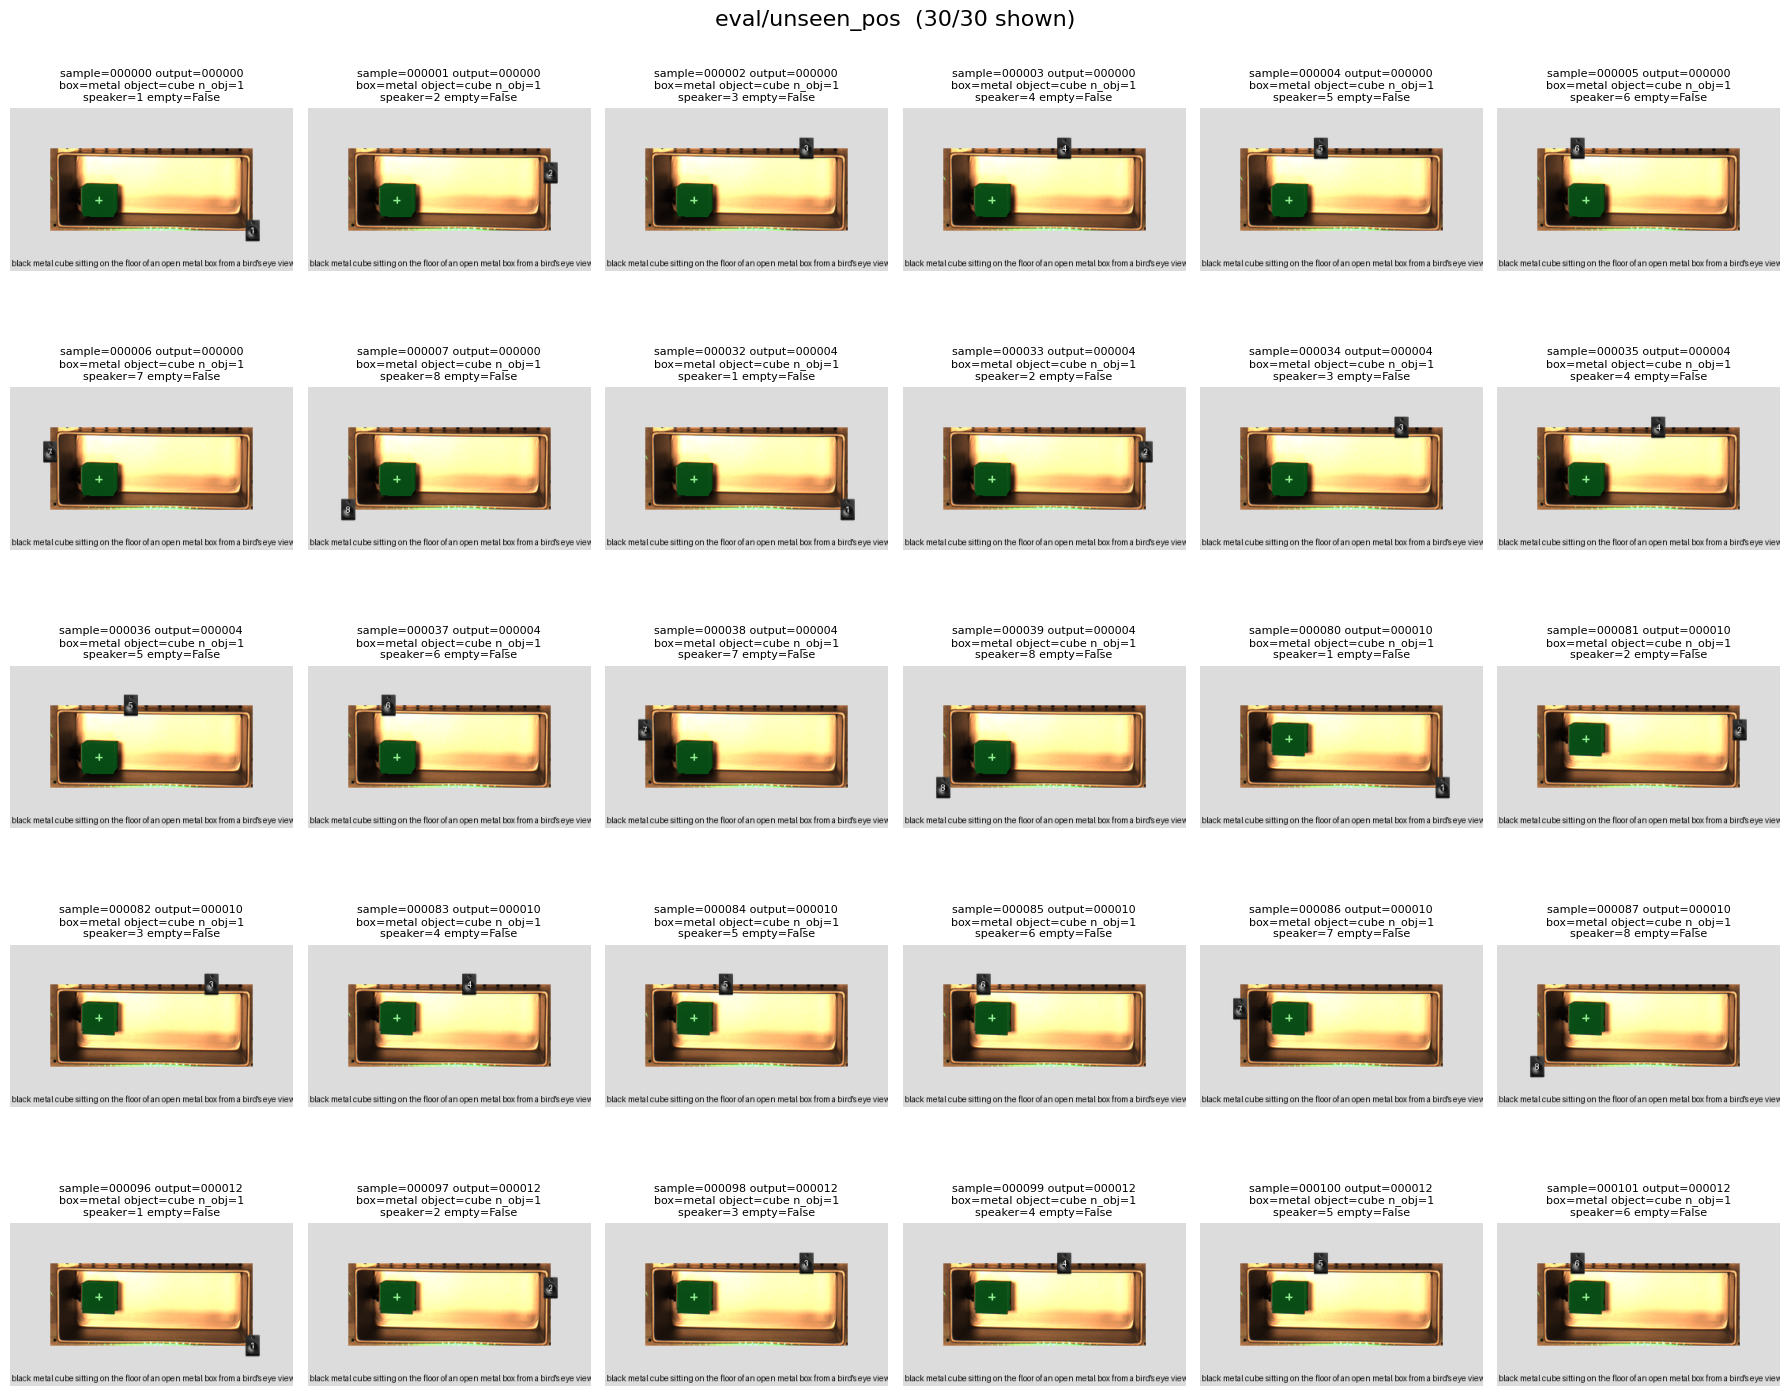

In [7]:
plot_split("eval/unseen_pos", splits["eval/unseen_pos"]);

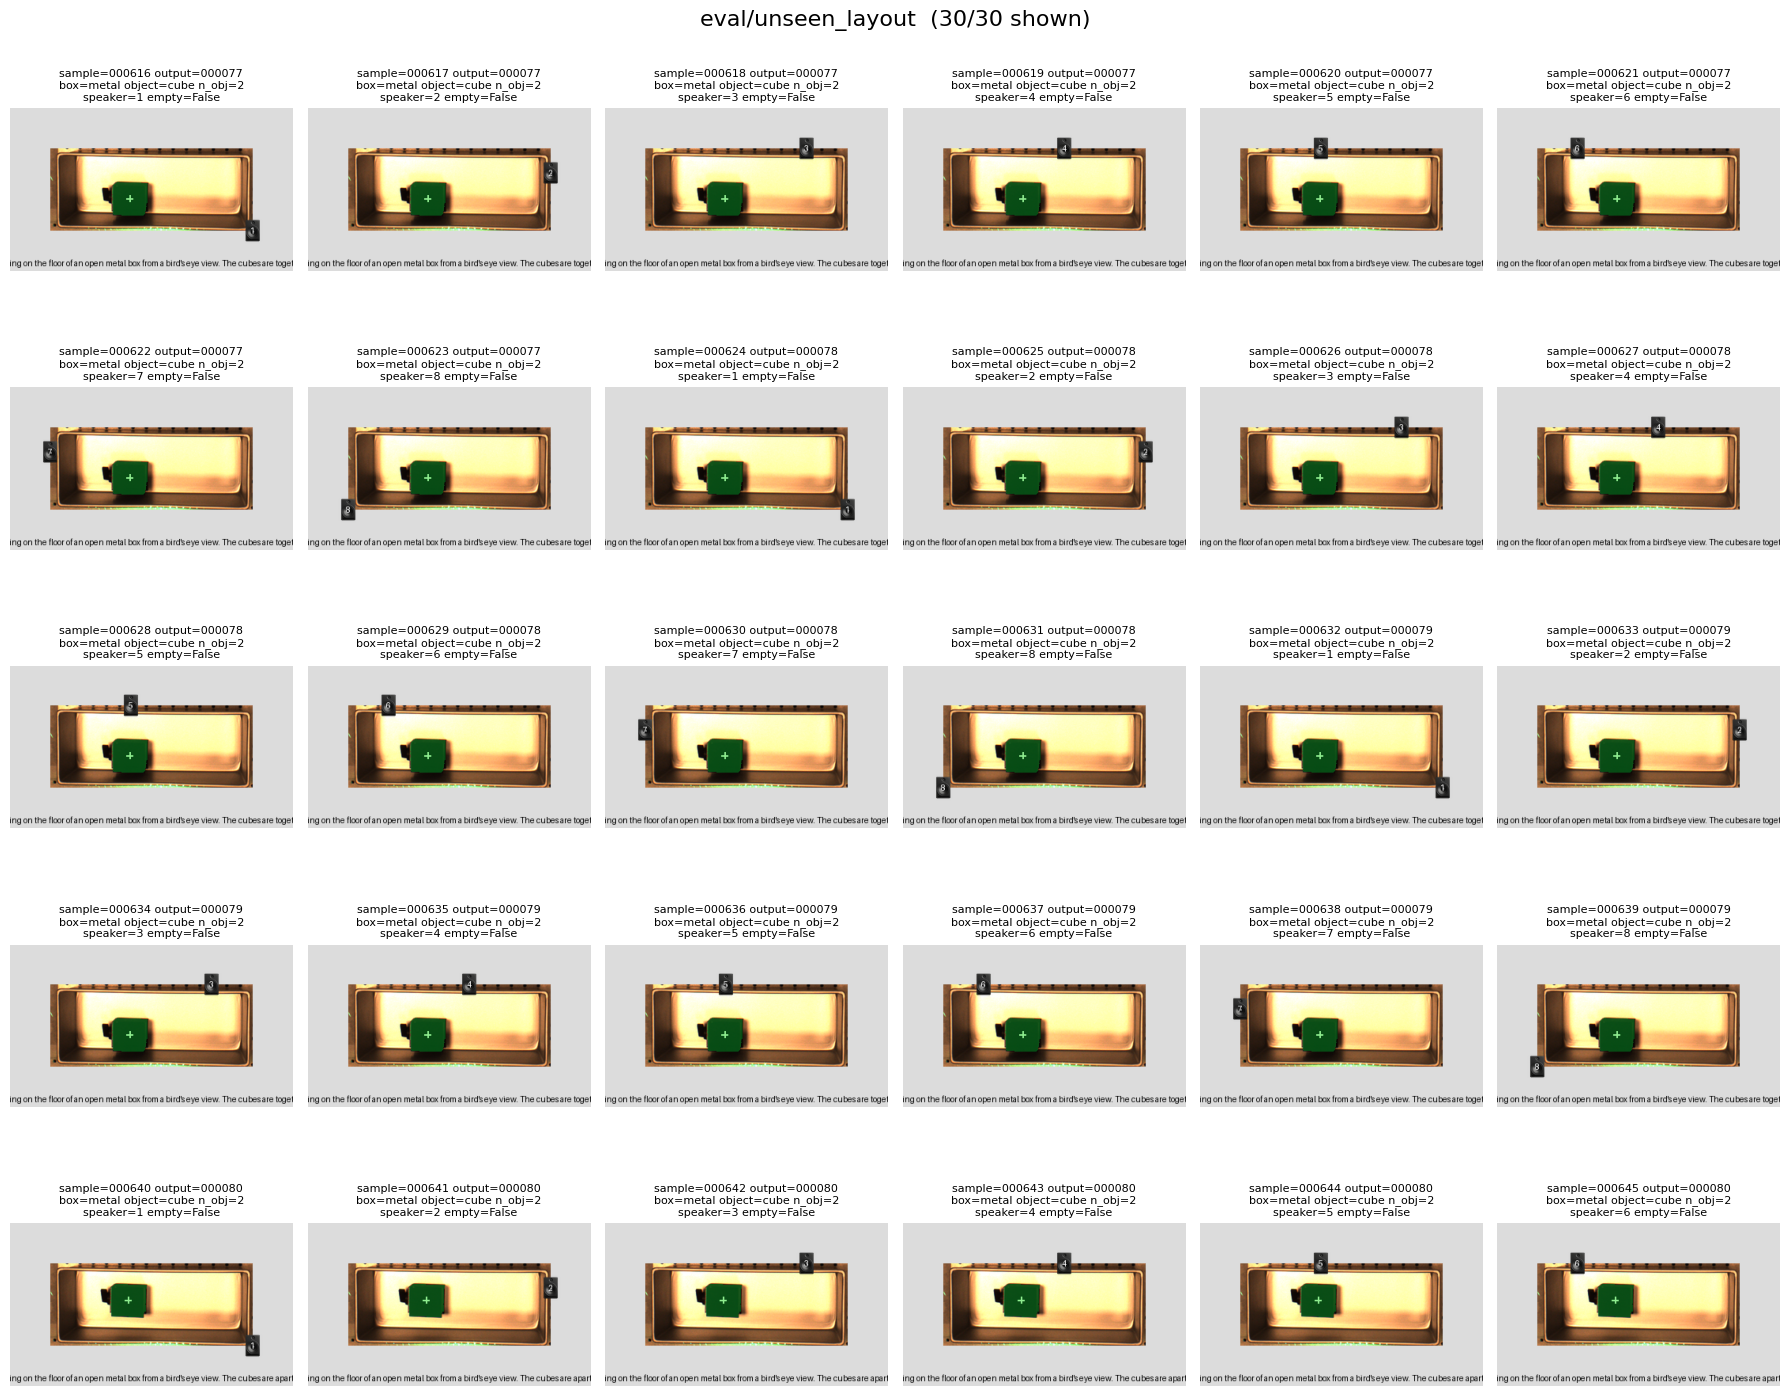

In [8]:
plot_split("eval/unseen_layout", splits["eval/unseen_layout"]);